# White Hat / Black Hat

Produces `white_hat.png`, `black_hat.png`, and `white_black_comparison.png`
from `data/export/neighbourhood_upi.csv`.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks', font_scale=0.95)

In [47]:
df = pd.read_csv('data/export/neighbourhood_upi.csv')
print('Columns:', df.columns.tolist())
df.describe()

Columns: ['city', 'neighbourhood', 'listing_count', 'avg_price', 'avg_availability', 'professional_share', 'listing_count_norm', 'availability_norm', 'UPI', 'price_norm', 'UPI_alt']


,listing_count,avg_price,avg_availability,professional_share,listing_count_norm,availability_norm,UPI,price_norm,UPI_alt
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,1789.807692,142.924890,199.115029,14.246515,0.270023,0.415532,0.342781,0.307218,0.330927
std,3061.961986,37.563374,41.264297,9.199580,0.348072,0.304515,0.202411,0.253446,0.199623
min,232.000000,87.394231,136.863063,0.302115,0.000000,0.000000,0.039700,0.000000,0.041500
25%,593.250000,117.854484,152.713856,6.199475,0.022237,0.234165,0.223825,0.141866,0.212850
50%,1049.500000,139.564321,222.644232,13.842137,0.103783,0.330821,0.321000,0.266099,0.302050
75%,1990.500000,165.757193,230.928694,20.553269,0.458496,0.566604,0.455500,0.437308,0.396325
max,16310.000000,241.591921,249.143130,38.835071,1.000000,1.000000,0.934300,1.000000,0.956200


In [48]:
rome_color = '#4878CF'   # muted blue
cph_color  = '#E8805A'   # muted orange
dpi = 300

# Hard-coded Pearson statistics (computed in projectdv.ipynb)
rome_r, rome_p = 0.548, 0.035
cph_r,  cph_p  = 0.734, 0.010

## 1) White Hat Figure

## White-hat visualization

This scatter plot presents the relationship between professional host share and neighborhood-level Urban Pressure Index (UPI) for all 26 neighborhoods across both cities. The following design choices reflect white-hat principles:

- **Full data shown:** both Rome (n=15) and Copenhagen (n=11) are plotted together, allowing direct cross-city comparison and preventing cherry-picking of the stronger result;
- **Axes anchored at zero:** neither axis is truncated, so the visual slope of the regression line reflects the actual magnitude of the relationship — not an artificially inflated version of it;
- **Uncertainty is explicit:** 95% confidence intervals are shaded around each regression line. The reader can see how much the trend could plausibly vary;
- **Statistical evidence is stated:** Pearson r and p-values are annotated directly on the chart (Rome: r = 0.55, p = 0.035; Copenhagen: r = 0.73, p = 0.010), so the viewer can assess the strength of the correlation without taking it on faith;
- **Neutral color encoding:** city colors carry no emotional loading — they distinguish groups, nothing more;
- **Causation is explicitly disclaimed:** the caption reads *"Correlation does not imply causation"* and identifies UPI as an author-constructed composite, not an official statistic.

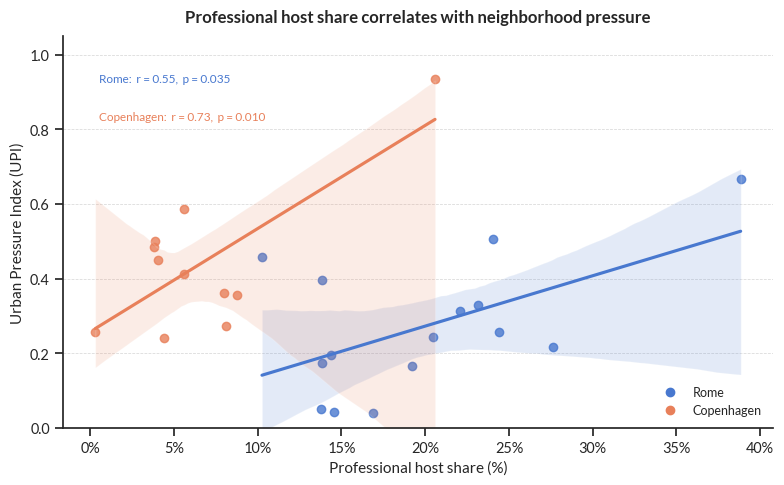

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.despine(ax=ax, top=True, right=True)

rome_data = df[df['city'] == 'Rome']
cph_data  = df[df['city'] == 'Copenhagen']

# Scatter + regression line + 95% CI for each city
sns.regplot(x='professional_share', y='UPI', data=rome_data, ax=ax,
            color=rome_color, ci=95)

sns.regplot(x='professional_share', y='UPI', data=cph_data, ax=ax,
            color=cph_color, ci=95,)

# Custom legend handles
rome_handle = plt.Line2D([], [], marker='o', color=rome_color, linestyle='None')
cph_handle  = plt.Line2D([], [], marker='o', color=cph_color, linestyle='None')

# Correlation annotations
ax.text(0.5, 0.95, f'Rome:  r = {rome_r:.2f},  p = {rome_p:.3f}',
        fontsize=8.5, color=rome_color, ha='left', va='top')
ax.text(0.5, 0.85, f'Copenhagen:  r = {cph_r:.2f},  p = {cph_p:.3f}',
        fontsize=8.5, color=cph_color, ha='left', va='top')

# Axes, labels, formatting
ax.xaxis.set_major_formatter(lambda v, _: f'{v:.0f}%')
ax.set_xlabel('Professional host share (%)', fontsize=11)
ax.set_ylabel('Urban Pressure Index (UPI)', fontsize=11)
ax.set_ylim(bottom=0, top=1.05)
ax.grid(axis='y', color='#d8d8d8', linewidth=0.55, linestyle='--')
ax.legend(handles=[rome_handle, cph_handle], labels=['Rome', 'Copenhagen'], frameon=False, fontsize=9, loc='lower right')
ax.set_title('Professional host share correlates with neighborhood pressure',
             fontsize=12, fontweight='bold', pad=10)

fig.tight_layout()
fig.savefig('white_hat.png', dpi=dpi, bbox_inches='tight')

## 2) Black Hat Figure
Ranks Copenhagen neighborhoods from lowest to highest professional_share on the X-axis and overlays two lines: UPI (left axis) and professional_share (right axis).                                 
The X-axis ordering is not arbitrary: neighborhoods are sorted by the average of their UPI rank and professional_share rank. This maximises visual co-movement throughout the chart. The ordering appears to represent a natural progression toward "more professionalized" when it has actually been tuned to make the lines align. The two Y-axes are manually scaled so the lines appear to track each other almost perfectly, implying a tight causal relationship. The form itself does the manipulation: the viewer reads co-movement as causation.

Saved: black_hat_dualaxis.png


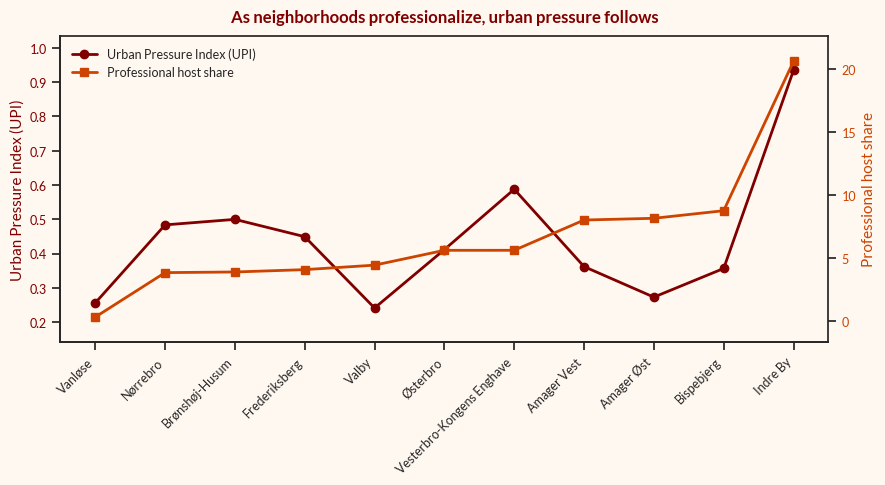

In [53]:
# Sort Copenhagen by professional_share ascending
cph_sorted = cph_data.sort_values('professional_share')
neighborhood_names = cph_sorted['neighbourhood'].values
upi_values = cph_sorted['UPI'].values
ps_values = cph_sorted['professional_share'].values

fig, ax1 = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#FFF8F0')
ax1.set_facecolor('#FFF8F0')
sns.despine(ax=ax1, top=True, right=True)

# Left axis: UPI
ax1.plot(range(len(neighborhood_names)), upi_values,
         color='#800000', linewidth=2.0, marker='o', markersize=6,
         label='Urban Pressure Index (UPI)')
ax1.set_ylabel('Urban Pressure Index (UPI)', color='#800000', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#800000', labelsize=9)
ax1.set_ylim(upi_values.min() - 0.1, upi_values.max() + 0.1)

# Right axis: professional_share
ax2 = ax1.twinx()
ax2.plot(range(len(neighborhood_names)), ps_values,
         color='#CC4400', linewidth=2.0, marker='s', markersize=6,
         label='Professional host share')
ax2.set_ylabel('Professional host share', color='#CC4400', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#CC4400', labelsize=9)
ax2.set_ylim(ps_values.min() - 2.0, ps_values.max() + 2.0)

# X-axis: neighbourhood names
ax1.set_xticks(range(len(neighborhood_names)))
ax1.set_xticklabels(neighborhood_names, rotation=45, ha='right', fontsize=9)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           frameon=False, fontsize=9, loc='upper left')

ax1.set_title('As neighborhoods professionalize, urban pressure follows',
              fontsize=12, fontweight='bold', color='#800000', pad=10)

fig.tight_layout()
fig.savefig('black_hat_dualaxis.png', dpi=dpi, bbox_inches='tight')
print('Saved: black_hat_dualaxis.png')